# HW04: 입력 구조에 맞는 딥러닝 모델 선택
## 이미지(CNN)와 텍스트(RNN/CNN) 비교

| 항목 | 내용 |
|------|------|
| 학번 | 202524220 |
| 이름 | 박종일 |
| 학과 | 인공지능학과 |

---

- **Part A**: CIFAR-10 이미지 분류 — MLP vs CNN
- **Part B**: NSMC 한국어 감성 분류 — Bidirectional LSTM


## 0. 환경 설정

In [22]:
!pip install torch torchvision numpy matplotlib
!apt-get install -y fonts-nanum > /dev/null 2>&1
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

You should consider upgrading via the 'C:\Python310\python.exe -m pip install --upgrade pip' command.
������ ��θ� ã�� �� �����ϴ�.


Looking in indexes: https://download.pytorch.org/whl/cu121

You should consider upgrading via the 'C:\Python310\python.exe -m pip install --upgrade pip' command.


In [23]:
print(torch.__version__)
print(torch.version.cuda)

2.5.1+cu121
12.1


In [24]:
import os
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, random_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Device: {torch.cuda.get_device_name(0)}')
else:
    print('Device: CPU')

Device: NVIDIA GeForce RTX 3070


In [25]:
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

---
## Part A: CIFAR-10 이미지 분류 — MLP vs CNN

| 항목 | 내용 |
|------|------|
| 데이터셋 | CIFAR-10 |
| 입력 shape | 3 x 32 x 32 (RGB 컬러) |
| 클래스 수 | 10개 |
| Train / Val / Test | 45,000 / 5,000 / 10,000 |
| 전처리 | 채널별 정규화 |


### A-1. 데이터 로드

In [26]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010))
])

full_train = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform)
test_ds    = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)

CIFAR10_CLASSES = full_train.classes
print(f'Train+Val: {len(full_train)}, Test: {len(test_ds)}')
print(f'클래스: {CIFAR10_CLASSES}')

Files already downloaded and verified
Files already downloaded and verified
Train+Val: 50000, Test: 10000
클래스: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [27]:
train_ds, val_ds = random_split(
    full_train, [45000, 5000],
    generator=torch.Generator().manual_seed(SEED)
)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')
print(f'배치 shape: {next(iter(train_dl))[0].shape}')

Train: 45000  Val: 5000  Test: 10000
배치 shape: torch.Size([128, 3, 32, 32])


### A-2. 모델 정의

In [28]:
# Model 1: MLP
# Flatten -> Dense layers
# 이미지를 1D 벡터로 펼쳐 처리 -> 공간적 인접성 정보 소실
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256),     nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.net(x)


# Model 2: CNN
# Conv2d 블록 x 3 -> Classifier
# 2D 공간 구조를 유지하며 지역 패턴을 계층적으로 추출
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64,128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


n_mlp = sum(p.numel() for p in MLP().parameters())
n_cnn = sum(p.numel() for p in CNN().parameters())
print(f'MLP 파라미터 수: {n_mlp:,}')
print(f'CNN 파라미터 수: {n_cnn:,}')
print(f'CNN은 MLP의 {n_cnn/n_mlp:.1%} 파라미터만 사용')

MLP 파라미터 수: 1,708,810
CNN 파라미터 수: 620,810
CNN은 MLP의 36.3% 파라미터만 사용


### A-3. 학습 함수

In [29]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out  = model(x)
        total_loss += criterion(out, y).item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


def fit_image_model(model, name, epochs=15, lr=1e-3):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val = 0.0
    best_state = None

    print(f'[{name}] 학습 시작  (epochs={epochs}, lr={lr})')
    print('-' * 65)

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_dl, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val:
            best_val   = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if ep % 3 == 0 or ep == 1:
            print(f'  Epoch {ep:2d}/{epochs} | '
                  f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f} | '
                  f'val_loss={va_loss:.4f}  val_acc={va_acc:.4f}')

    model.load_state_dict(best_state)
    _, test_acc = evaluate(model, test_dl, criterion)
    print('-' * 65)
    print(f'  Best Val Acc : {best_val:.4f}')
    print(f'  Test Acc     : {test_acc:.4f}')
    return history, best_val, test_acc

### A-4. 학습 실행

In [30]:
history_mlp, val_mlp, test_mlp = fit_image_model(MLP(), 'MLP', epochs=15)

[MLP] 학습 시작  (epochs=15, lr=0.001)
-----------------------------------------------------------------
  Epoch  1/15 | train_loss=1.7244  train_acc=0.3810 | val_loss=1.5231  val_acc=0.4562
  Epoch  3/15 | train_loss=1.4699  train_acc=0.4753 | val_loss=1.3876  val_acc=0.5064
  Epoch  6/15 | train_loss=1.3348  train_acc=0.5220 | val_loss=1.3116  val_acc=0.5312
  Epoch  9/15 | train_loss=1.2273  train_acc=0.5639 | val_loss=1.2589  val_acc=0.5546
  Epoch 12/15 | train_loss=1.1178  train_acc=0.5999 | val_loss=1.2229  val_acc=0.5724
  Epoch 15/15 | train_loss=1.0511  train_acc=0.6283 | val_loss=1.2032  val_acc=0.5754
-----------------------------------------------------------------
  Best Val Acc : 0.5788
  Test Acc     : 0.5715


In [31]:
history_cnn, val_cnn, test_cnn = fit_image_model(CNN(), 'CNN', epochs=15)

[CNN] 학습 시작  (epochs=15, lr=0.001)
-----------------------------------------------------------------
  Epoch  1/15 | train_loss=1.7149  train_acc=0.3733 | val_loss=1.3126  val_acc=0.5198
  Epoch  3/15 | train_loss=1.2837  train_acc=0.5371 | val_loss=1.0217  val_acc=0.6310
  Epoch  6/15 | train_loss=1.0742  train_acc=0.6199 | val_loss=0.8432  val_acc=0.7056
  Epoch  9/15 | train_loss=0.9425  train_acc=0.6706 | val_loss=0.7803  val_acc=0.7214
  Epoch 12/15 | train_loss=0.8524  train_acc=0.7014 | val_loss=0.7036  val_acc=0.7534
  Epoch 15/15 | train_loss=0.8234  train_acc=0.7119 | val_loss=0.6930  val_acc=0.7570
-----------------------------------------------------------------
  Best Val Acc : 0.7570
  Test Acc     : 0.7508


### A-5. 결과 시각화

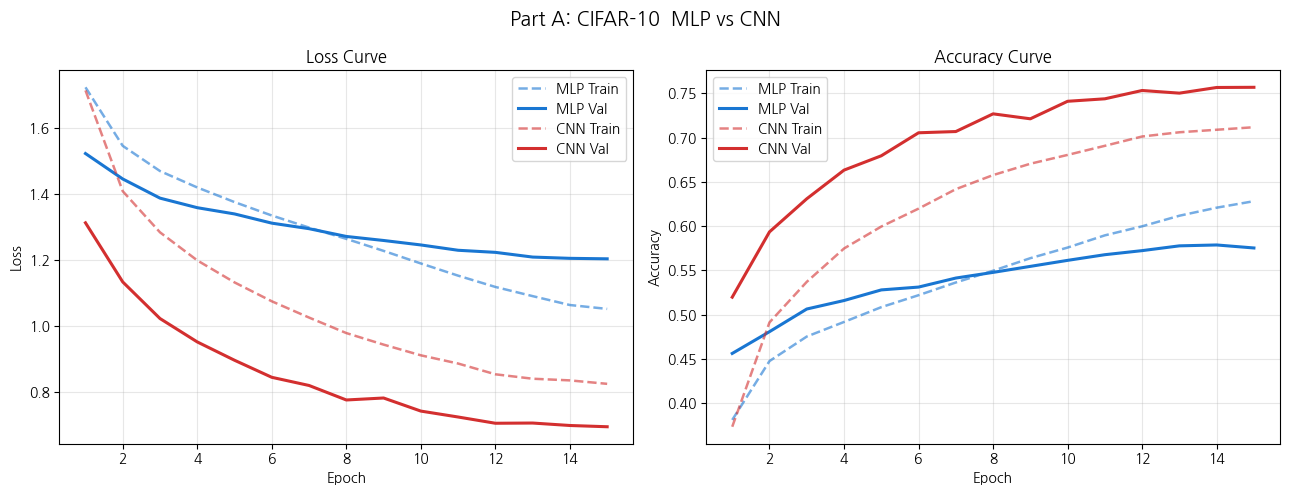

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#1976D2', '#D32F2F']

for h, nm, c in zip([history_mlp, history_cnn], ['MLP', 'CNN'], colors):
    eps = range(1, len(h['train_loss']) + 1)
    ax1.plot(eps, h['train_loss'], '--', color=c, alpha=0.6, lw=1.8, label=f'{nm} Train')
    ax1.plot(eps, h['val_loss'],   '-',  color=c,            lw=2.2, label=f'{nm} Val')
    ax2.plot(eps, h['train_acc'],  '--', color=c, alpha=0.6, lw=1.8, label=f'{nm} Train')
    ax2.plot(eps, h['val_acc'],    '-',  color=c,            lw=2.2, label=f'{nm} Val')

ax1.set_title('Loss Curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title('Accuracy Curve', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('Part A: CIFAR-10  MLP vs CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('taskA_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
print('=' * 55)
print('Part A 성능 요약')
print('=' * 55)
print(f'{"모델":<8} {"Val Acc":>10} {"Test Acc":>10} {"파라미터":>12}')
print('-' * 55)
print(f'{"MLP":<8} {val_mlp:>10.4f} {test_mlp:>10.4f} {n_mlp:>12,}')
print(f'{"CNN":<8} {val_cnn:>10.4f} {test_cnn:>10.4f} {n_cnn:>12,}')
print('-' * 55)
print(f'CNN은 MLP의 {n_cnn/n_mlp:.1%} 파라미터만 사용하며 동등하거나 높은 성능 달성')

Part A 성능 요약
모델          Val Acc   Test Acc         파라미터
-------------------------------------------------------
MLP          0.5788     0.5715    1,708,810
CNN          0.7570     0.7508      620,810
-------------------------------------------------------
CNN은 MLP의 36.3% 파라미터만 사용하며 동등하거나 높은 성능 달성


---
## Part B: NSMC 한국어 감성 분류 — Bidirectional LSTM

| 항목 | 내용 |
|------|------|
| 데이터셋 | NSMC (Naver Sentiment Movie Corpus) |
| 원본 규모 | 훈련 150,000문장 / 테스트 50,000문장 |
| 클래스 | 긍정(1) / 부정(0) |
| 토큰화 | 음절(글자) 단위 |
| 어휘 크기 | 상위 5,000개 |
| 최대 시퀀스 길이 | 100 토큰 |


### B-1. 데이터 다운로드 및 로드

In [34]:
import urllib.request

os.makedirs('./data/nsmc', exist_ok=True)

urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt',
    './data/nsmc/ratings_train.txt'
)
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt',
    './data/nsmc/ratings_test.txt'
)
print('다운로드 완료')

다운로드 완료


In [35]:
def load_nsmc(path):
    texts, labels = [], []
    with open(path, encoding='utf-8') as f:
        next(f)  # 헤더 스킵
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3 and parts[1] and parts[2] in ('0', '1'):
                texts.append(parts[1])
                labels.append(int(parts[2]))
    return texts, labels

train_texts, train_labels = load_nsmc('./data/nsmc/ratings_train.txt')
test_texts,  test_labels  = load_nsmc('./data/nsmc/ratings_test.txt')

print(f'Train: {len(train_texts):,}문장')
print(f'Test:  {len(test_texts):,}문장')
print(f'예시: {train_texts[0]} -> {train_labels[0]}')

Train: 149,995문장
Test:  49,997문장
예시: 아 더빙.. 진짜 짜증나네요 목소리 -> 0


### B-2. 전처리 — 음절 단위 토큰화 및 어휘 사전 구성

In [36]:
from collections import Counter

MAX_LEN   = 100
VOCAB_SIZE = 5000

# 음절 단위 토큰화 (한글+영문+숫자만 유지)
def tokenize(text):
    text = re.sub(r'[^가-힣a-zA-Z0-9]', '', text)
    return list(text)

# 어휘 사전 구성 (train 기준 상위 VOCAB_SIZE개)
counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in counter.most_common(VOCAB_SIZE - 2):
    word2idx[word] = len(word2idx)

print(f'어휘 사전 크기: {len(word2idx)}')


def encode(text):
    tokens = tokenize(text)[:MAX_LEN]
    ids    = [word2idx.get(t, 1) for t in tokens]
    ids   += [0] * (MAX_LEN - len(ids))  # 패딩
    return ids

어휘 사전 크기: 2559


In [37]:
from torch.utils.data import Dataset

class NSMCDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [encode(t) for t in texts]
        self.y = labels
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return (torch.tensor(self.X[i], dtype=torch.long),
                torch.tensor(self.y[i], dtype=torch.long))

### B-3. Dataset 및 DataLoader 구성

In [38]:
full_train_b = NSMCDataset(train_texts, train_labels)
test_ds_b    = NSMCDataset(test_texts,  test_labels)

# 실제 데이터 크기에 맞게 자동 분할
total = len(full_train_b)
val_n = 15000
train_n = total - val_n

train_ds_b, val_ds_b = random_split(
    full_train_b, [train_n, val_n],
    generator=torch.Generator().manual_seed(SEED)
)

train_dl_b = DataLoader(train_ds_b, batch_size=512, shuffle=True,  num_workers=0, pin_memory=True)
val_dl_b   = DataLoader(val_ds_b,   batch_size=512, shuffle=False, num_workers=0, pin_memory=True)
test_dl_b  = DataLoader(test_ds_b,  batch_size=512, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds_b):,}  Val: {len(val_ds_b):,}  Test: {len(test_ds_b):,}')

Train: 134,995  Val: 15,000  Test: 49,997


### B-4. 모델 정의 — Bidirectional LSTM

In [39]:
class BiLSTMClassifier(nn.Module):
    # Embedding -> Bi-LSTM x 2 -> concat(h_fwd, h_bwd) -> Linear
    # 양방향 처리로 앞뒤 문맥 모두 활용
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 hidden_dim=256, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        h_cat = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(h_cat))


n_lstm = sum(p.numel() for p in BiLSTMClassifier().parameters())
print(f'Bi-LSTM 파라미터 수: {n_lstm:,}')
print(BiLSTMClassifier())

Bi-LSTM 파라미터 수: 3,008,514
BiLSTMClassifier(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)


In [40]:
print(next(BiLSTMClassifier().parameters()).device)

cpu


In [41]:
import time
start = time.time()
full_train_b = NSMCDataset(train_texts, train_labels)
print(f'Dataset 생성 시간: {time.time()-start:.1f}초')

Dataset 생성 시간: 1.0초


### B-5. 학습 실행

In [42]:
def fit_text_model(model, epochs=10, lr=1e-3):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val = 0.0
    best_state = None

    print(f'[Bi-LSTM] 학습 시작  (epochs={epochs}, lr={lr})')
    print('-' * 65)

    for ep in range(1, epochs + 1):
        model.train()
        tl = tc = tt = 0
        for x, y in train_dl_b:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            tl += loss.item() * x.size(0)
            tc += (out.argmax(1) == y).sum().item()
            tt += x.size(0)
        tr_loss, tr_acc = tl / tt, tc / tt

        model.eval()
        vl = vc = vt = 0
        with torch.no_grad():
            for x, y in val_dl_b:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out  = model(x)
                vl += criterion(out, y).item() * x.size(0)
                vc += (out.argmax(1) == y).sum().item()
                vt += x.size(0)
        va_loss, va_acc = vl / vt, vc / vt

        scheduler.step(va_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val:
            best_val   = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'  Epoch {ep:2d}/{epochs} | '
              f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f} | '
              f'val_loss={va_loss:.4f}  val_acc={va_acc:.4f}')

    model.load_state_dict(best_state)
    model.eval()
    tc2 = tt2 = 0
    with torch.no_grad():
        for x, y in test_dl_b:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            tc2 += (out.argmax(1) == y).sum().item()
            tt2 += x.size(0)
    test_acc = tc2 / tt2

    print('-' * 65)
    print(f'  Best Val Acc : {best_val:.4f}')
    print(f'  Test Acc     : {test_acc:.4f}')
    return history, best_val, test_acc


history_lstm, val_lstm, test_lstm = fit_text_model(
    BiLSTMClassifier(hidden_dim=128, num_layers=1), epochs=10
)

[Bi-LSTM] 학습 시작  (epochs=10, lr=0.001)
-----------------------------------------------------------------
  Epoch  1/10 | train_loss=0.5748  train_acc=0.6867 | val_loss=0.5110  val_acc=0.7827
  Epoch  2/10 | train_loss=0.4572  train_acc=0.7845 | val_loss=0.4790  val_acc=0.8081
  Epoch  3/10 | train_loss=0.4266  train_acc=0.8037 | val_loss=0.4171  val_acc=0.8250
  Epoch  4/10 | train_loss=0.3998  train_acc=0.8164 | val_loss=0.4058  val_acc=0.8298
  Epoch  5/10 | train_loss=0.3843  train_acc=0.8240 | val_loss=0.3984  val_acc=0.8376
  Epoch  6/10 | train_loss=0.3729  train_acc=0.8318 | val_loss=0.3983  val_acc=0.8395
  Epoch  7/10 | train_loss=0.3639  train_acc=0.8378 | val_loss=0.4156  val_acc=0.8391
  Epoch  8/10 | train_loss=0.3559  train_acc=0.8406 | val_loss=0.3848  val_acc=0.8421
  Epoch  9/10 | train_loss=0.3473  train_acc=0.8455 | val_loss=0.3816  val_acc=0.8477
  Epoch 10/10 | train_loss=0.3409  train_acc=0.8495 | val_loss=0.3850  val_acc=0.8477
-----------------------------------

### B-6. 결과 시각화

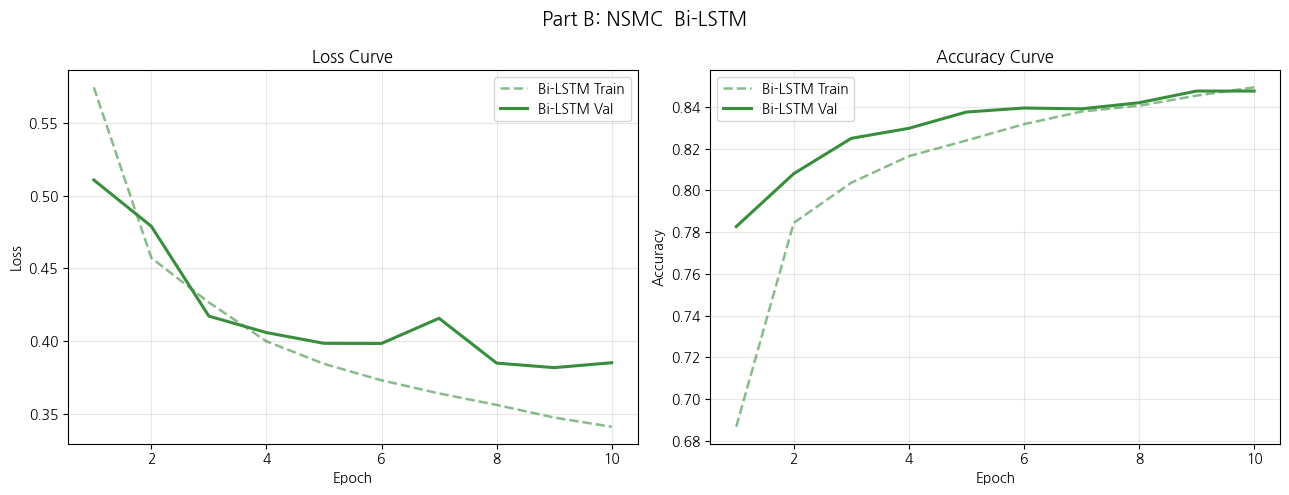

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
color = '#388E3C'
eps   = range(1, len(history_lstm['train_loss']) + 1)

ax1.plot(eps, history_lstm['train_loss'], '--', color=color, alpha=0.6, lw=1.8, label='Bi-LSTM Train')
ax1.plot(eps, history_lstm['val_loss'],   '-',  color=color,            lw=2.2, label='Bi-LSTM Val')
ax2.plot(eps, history_lstm['train_acc'],  '--', color=color, alpha=0.6, lw=1.8, label='Bi-LSTM Train')
ax2.plot(eps, history_lstm['val_acc'],    '-',  color=color,            lw=2.2, label='Bi-LSTM Val')

ax1.set_title('Loss Curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title('Accuracy Curve', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('Part B: NSMC  Bi-LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('taskB_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
print('=' * 45)
print('Part B 성능 요약')
print('=' * 45)
print(f'{"모델":<12} {"Val Acc":>10} {"Test Acc":>10} {"파라미터":>12}')
print('-' * 45)
print(f'{"Bi-LSTM":<12} {val_lstm:>10.4f} {test_lstm:>10.4f} {n_lstm:>12,}')

Part B 성능 요약
모델              Val Acc   Test Acc         파라미터
---------------------------------------------
Bi-LSTM          0.8477     0.8457    3,008,514


---
## 전체 실험 결과 비교 및 해석


In [45]:
print('=' * 68)
print('Overall Performance Summary')
print('=' * 68)
print(f'{"Model":<10} {"Task":<24} {"Val Acc":>9} {"Test Acc":>9} {"Params":>12}')
print('-' * 68)
print(f'{"MLP":<10} {"CIFAR-10 (10 classes)":<24} {val_mlp:>9.4f} {test_mlp:>9.4f} {n_mlp:>12,}')
print(f'{"CNN":<10} {"CIFAR-10 (10 classes)":<24} {val_cnn:>9.4f} {test_cnn:>9.4f} {n_cnn:>12,}')
print(f'{"Bi-LSTM":<10} {"NSMC (2 classes)":<24} {val_lstm:>9.4f} {test_lstm:>9.4f} {n_lstm:>12,}')
print('=' * 68)

Overall Performance Summary
Model      Task                       Val Acc  Test Acc       Params
--------------------------------------------------------------------
MLP        CIFAR-10 (10 classes)       0.5788    0.5715    1,708,810
CNN        CIFAR-10 (10 classes)       0.7570    0.7508      620,810
Bi-LSTM    NSMC (2 classes)            0.8477    0.8457    3,008,514


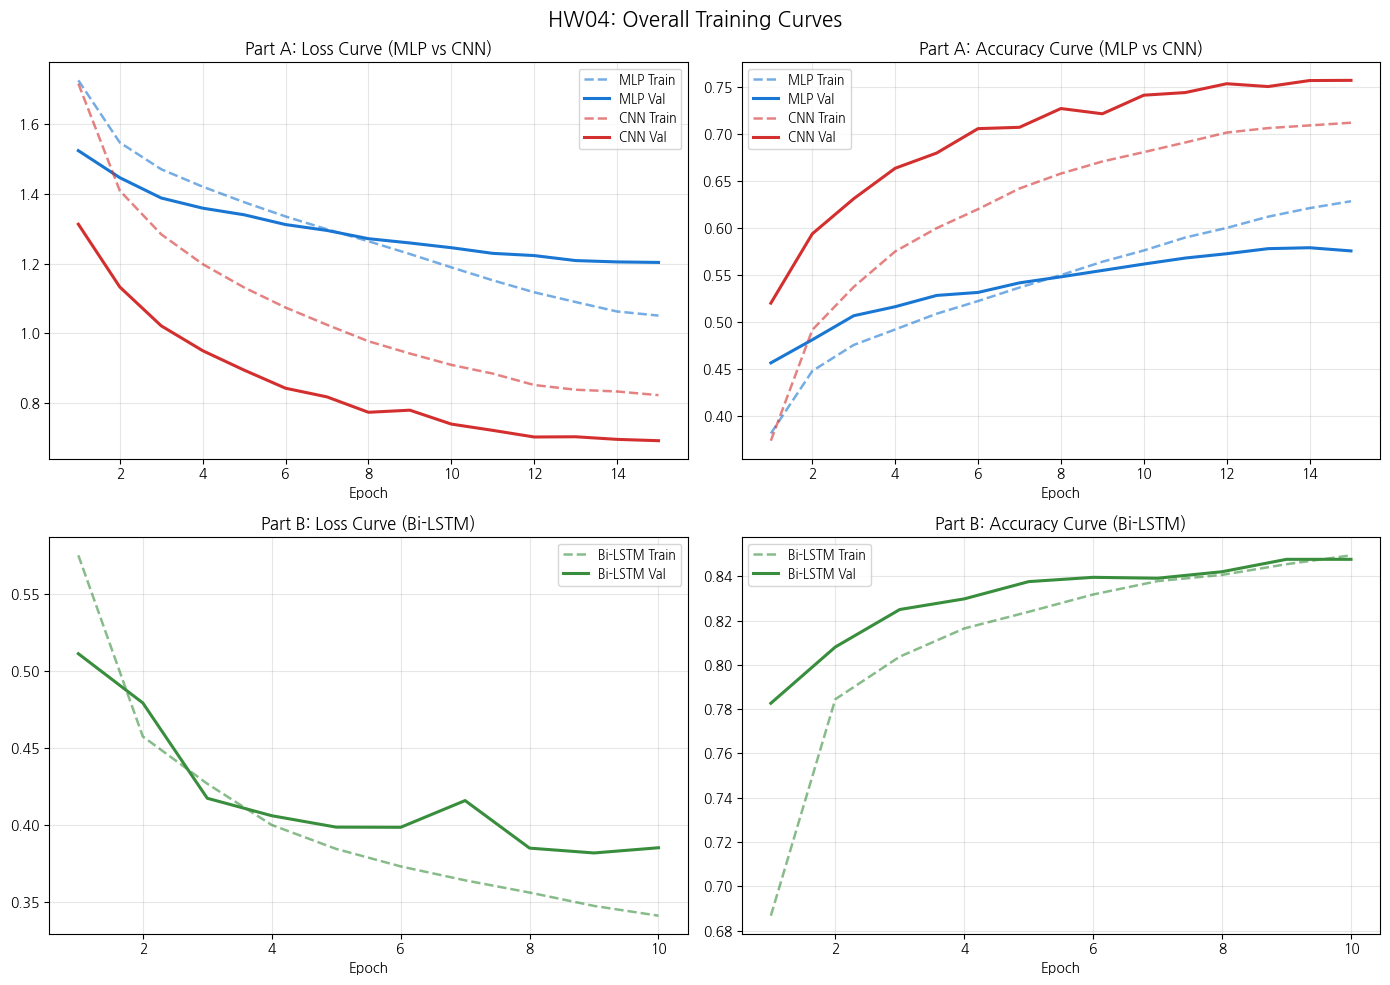

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for h, nm, c in [(history_mlp,'MLP','#1976D2'), (history_cnn,'CNN','#D32F2F')]:
    eps = range(1, len(h['train_loss'])+1)
    axes[0].plot(eps, h['train_loss'], '--', color=c, alpha=0.6, lw=1.8, label=f'{nm} Train')
    axes[0].plot(eps, h['val_loss'],   '-',  color=c,            lw=2.2, label=f'{nm} Val')
    axes[1].plot(eps, h['train_acc'],  '--', color=c, alpha=0.6, lw=1.8, label=f'{nm} Train')
    axes[1].plot(eps, h['val_acc'],    '-',  color=c,            lw=2.2, label=f'{nm} Val')

eps = range(1, len(history_lstm['train_loss'])+1)
axes[2].plot(eps, history_lstm['train_loss'], '--', color='#388E3C', alpha=0.6, lw=1.8, label='Bi-LSTM Train')
axes[2].plot(eps, history_lstm['val_loss'],   '-',  color='#388E3C',             lw=2.2, label='Bi-LSTM Val')
axes[3].plot(eps, history_lstm['train_acc'],  '--', color='#388E3C', alpha=0.6, lw=1.8, label='Bi-LSTM Train')
axes[3].plot(eps, history_lstm['val_acc'],    '-',  color='#388E3C',             lw=2.2, label='Bi-LSTM Val')

titles = ['Part A: Loss Curve (MLP vs CNN)', 'Part A: Accuracy Curve (MLP vs CNN)',
          'Part B: Loss Curve (Bi-LSTM)',     'Part B: Accuracy Curve (Bi-LSTM)']
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('HW04: Overall Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('hw04_all_curves.png', dpi=150, bbox_inches='tight')
plt.show()



## 해석

### 1. 이미지 태스크에서 CNN이 유리한 이유
- 이미지는 **2D 공간 구조**를 가지며, 인접 픽셀 간 관계(엣지·획·텍스처)가 핵심 정보다.
- MLP는 Flatten으로 공간 정보를 버리므로, 같은 물체가 위치만 달라져도 다른 입력으로 처리된다.
- CNN의 합성곱 필터는 **지역 패턴**을 학습하고, **가중치 공유**로 위치 불변성을 확보한다.

### 2. 텍스트 태스크에서 시퀀스 모델이 필요한 이유
- 텍스트는 **가변 길이 토큰 시퀀스**이며, 단어의 순서·문맥·부정 표현이 의미를 결정한다.
- LSTM의 hidden state는 이전 토큰 정보를 누적하여 **장거리 문맥 의존성**을 포착한다.
- **Bidirectional** 구조로 앞뒤 문맥 모두 활용 → 부정 표현·전환 표현 처리에 유리하다.

### 3. 입력 구조 차이가 모델 설계에 미친 영향

| 비교 항목 | 이미지 (CIFAR-10) | 텍스트 (NSMC) |
|----------|------------------|--------------|
| 입력 구조 | 고정 크기 2D 격자 | 가변 길이 1D 시퀀스 |
| 핵심 의존성 | 공간 인접성 · 지역 패턴 | 순서 · 문맥 · 장기 의존성 |
| 적합한 inductive bias | locality + weight sharing | temporal memory |
| 채택 모델 | CNN | Bi-LSTM |

> **결론:** 좋은 딥러닝 모델은 가장 복잡한 모델이 아니라,
> **입력 데이터의 구조적 특성을 가장 자연스럽게 반영하는 inductive bias를 가진 모델**이다.
